# 03 - Treinamento e avaliação

Pré-requisitos:
- projeto criado
- labels revisados
- `config.yaml` ajustado

### Célula 1 — imports

In [3]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import deeplabcut
import tqdm

ROOT_NOTEBOOK = Path.cwd().resolve().parent
if str(ROOT_NOTEBOOK) not in sys.path:
    sys.path.append(str(ROOT_NOTEBOOK))

from src.paths import CONFIG_PATH, PROJECT_DIR, show_paths

show_paths()
assert CONFIG_PATH.exists(), f"config.yaml não encontrado: {CONFIG_PATH}"

ROOT_DIR: C:\Users\edoal\ProjetosPy\bab_dlc1
VIDEOS_DIR: C:\Users\edoal\ProjetosPy\bab_dlc1\videos
RESULTS_DIR: C:\Users\edoal\ProjetosPy\bab_dlc1\results
PROJECT_DIR: C:\Users\edoal\ProjetosPy\bab_dlc1\bab_bar_only-Edo-2026-03-08
CONFIG_PATH: C:\Users\edoal\ProjetosPy\bab_dlc1\bab_bar_only-Edo-2026-03-08\config.yaml


### Célula 2 — criar dataset de treino

In [4]:
deeplabcut.create_training_dataset(str(CONFIG_PATH))

[(0.8,
  1,
  (array([28, 11, 10, 41,  2, 27, 38, 31, 22,  4, 33, 35, 26, 34, 18,  7, 14,
          45, 48, 29, 15, 30, 32, 16, 42, 20, 43,  8, 13, 25,  5, 17, 40, 49,
           1, 12, 37, 24,  6, 23]),
   array([36, 21, 19,  9, 39, 46,  3,  0, 47, 44])))]

### Célula 3 — treinar

In [6]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

deeplabcut.train_network(str(CONFIG_PATH))

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
device: auto
inference:
  multithreading:
    enabled: True
    queue_length: 4
    timeout: 30.0
  compile:
    enabled: False
    backend: inductor
  autocast:
    enabled: False
metadata:
  project_path: C:\Users\edoal\ProjetosPy\bab_dlc1\bab_bar_only-Edo-2026-03-08
  pose_config_path: C:\Users\edoal\ProjetosPy\bab_dlc1\bab_bar_only-Edo-2026-03-08\dlc-models-pytorch\iteration-0\bab_bar_onlyMar8-trainset80shuffle1\train\pytorch_config.yaml
  bodyparts: ['beam_left', 'beam_center', 'beam_right']
  unique_bodyparts: []
  individuals: ['animal']
  with_identity: None
method: bu
model:
  backbone:
    type: ResNe

### Célula 4 — localizar pasta de treino

In [8]:
train_root = PROJECT_DIR / "dlc-models-pytorch" / "iteration-0"
assert train_root.exists(), f"Pasta não encontrada: {train_root}"

all_train_dirs = sorted(train_root.rglob("train"))
assert all_train_dirs, "Nenhuma pasta train/ encontrada."

train_dir = all_train_dirs[0]
print("train_dir:", train_dir)

train_dir: C:\Users\edoal\ProjetosPy\bab_dlc1\bab_bar_only-Edo-2026-03-08\dlc-models-pytorch\iteration-0\bab_bar_onlyMar8-trainset80shuffle1\train


### Célula 5 — ler learning stats

In [9]:
stats_csv = train_dir / "learning_stats.csv"
assert stats_csv.exists(), f"Arquivo não encontrado: {stats_csv}"

df = pd.read_csv(stats_csv)

print(df.columns.tolist())

val_like = [c for c in df.columns if "val" in c.lower() or "valid" in c.lower() or "eval" in c.lower()]
print("Colunas tipo val/eval:", val_like)

for c in val_like:
    print(c, "NaNs:", df[c].isna().sum(), "/", len(df))

['step', 'losses/eval.bodypart_heatmap', 'losses/eval.bodypart_locref', 'losses/eval.bodypart_total_loss', 'losses/eval.total_loss', 'losses/train.bodypart_heatmap', 'losses/train.bodypart_locref', 'losses/train.bodypart_total_loss', 'losses/train.total_loss', 'metrics/test.mAP', 'metrics/test.mAR', 'metrics/test.rmse', 'metrics/test.rmse_pcutoff']
Colunas tipo val/eval: ['losses/eval.bodypart_heatmap', 'losses/eval.bodypart_locref', 'losses/eval.bodypart_total_loss', 'losses/eval.total_loss']
losses/eval.bodypart_heatmap NaNs: 90 / 100
losses/eval.bodypart_locref NaNs: 90 / 100
losses/eval.bodypart_total_loss NaNs: 90 / 100
losses/eval.total_loss NaNs: 90 / 100


### Célula 6 — curva de aprendizagem

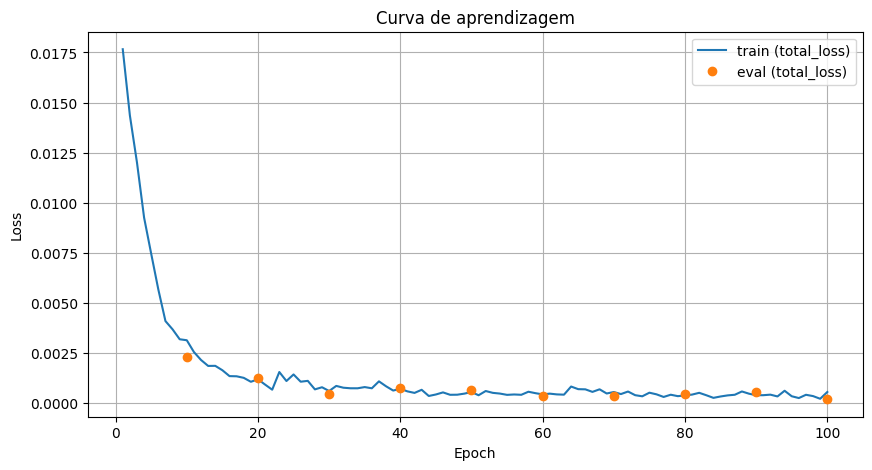

In [12]:
x = df["step"].to_numpy()
train = df["losses/train.total_loss"].to_numpy()
val   = df["losses/eval.total_loss"].to_numpy()

plt.figure(figsize=(10,5))
plt.plot(x, train, label="train (total_loss)")
mask = np.isfinite(val)
plt.plot(x[mask], val[mask], "o", label="eval (total_loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Curva de aprendizagem")
plt.grid(True)
plt.legend()
plt.show()

### Célula 7 — avaliar rede

In [16]:
deeplabcut.evaluate_network(str(CONFIG_PATH), Shuffles=[1], plotting=True, snapshotindex=2)

Evaluation scorer: DLC_Resnet50_bab_bar_onlyMar8shuffle1_snapshot_100


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:11<00:00,  1.15s/it]


Evaluation results file: DLC_Resnet50_bab_bar_onlyMar8shuffle1_snapshot_100-results.csv
Evaluation results for DLC_Resnet50_bab_bar_onlyMar8shuffle1_snapshot_100-results.csv (pcutoff: 0.6):
train rmse              0.50
train rmse_pcutoff      0.50
train mAP             100.00
train mAR             100.00
test rmse               0.46
test rmse_pcutoff       0.46
test mAP              100.00
test mAR              100.00
Name: (0.8, 1, 100, -1, 0.6), dtype: float64
